# Statistical Mechanics of Market Microstructure
**Author:** Esteban Cardenas | **Degree:** MSc Physics of Data

This notebook demonstrates a production-ready quantitative finance pipeline. It ingests high-frequency tick data (millions of rows), optimizes memory via downcasting, and applies statistical physics principles to challenge classical time-series assumptions. 

We will prove that parameterizing market data by economic energy (Dollar Bars) recovers Gaussian normality, filter out microscopic thermal jitter (Bid-Ask bounce), and deploy a Ridge Regression model to predict short-term kinematics using Order Flow Imbalance (OFI).


In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..')) # Move up one directory to access 'src'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import acf

from src.tick_wrangler import HighFreqTickWrangler
from src.microstructure import (
    create_time_bars, 
    create_volume_bars, 
    create_dollar_bars, 
    analyze_bar_normality,
    calculate_volatility_signature
)
from src.modeling import predictive_ofi_modeling

%matplotlib inline


## Phase 1: Data Ingestion & Memory Optimization
We instantiate the `HighFreqTickWrangler` to download raw tick data from Binance, handle timestamp schema drift, and optimize Pandas memory consumption by explicitly downcasting 64-bit floats to 32-bit.


In [2]:
# Initialize for Bitcoin (January 1st, 2026 - or change to any date)
wrangler = HighFreqTickWrangler(symbol="BTCUSDT", date="2026-01-01")

# Execute Pipeline
if wrangler.download_binance_trades():
    wrangler.load_and_optimize()
    wrangler.engineer_features()

# Display a preview of the clean, vectorized data
wrangler.df.head()


Download and extraction complete.
Loading data into memory...
Loaded 1,449,281 rows. Memory usage: 23.50 MB
Engineering features using vectorized operations...
Feature engineering completed in 0.0358 seconds.


,price,qty,is_buyer_maker,trade_direction,signed_volume,cvd,rolling_vwap
timestamp,,,,,,,
2026-01-01 00:00:00.039409,87648.210938,0.08185,True,-1,-0.08185,-0.08185,87648.208716
2026-01-01 00:00:00.272386,87648.218750,0.00013,False,1,0.00013,-0.08172,87648.208727
2026-01-01 00:00:00.276733,87648.218750,0.00023,False,1,0.00023,-0.08149,87648.208746
2026-01-01 00:00:00.396949,87648.218750,0.01032,False,1,0.01032,-0.07117,87648.210022
2026-01-01 00:00:00.401005,87648.218750,0.00206,False,1,0.00206,-0.06911,87648.210270


## Phase 2: Event-Based Resampling & Gaussian Recovery
Classical finance samples by physical time ($dt$), leading to heteroskedasticity and fat tails (extreme risk). By sampling based on economic throughput (Dollar Bars), we parameterize the system by its "arc length," mathematically absorbing volatility bursts.


In [3]:
# Generate the bar schemas
time_bars = create_time_bars(wrangler.df, freq='1min')
vol_bars = create_volume_bars(wrangler.df, volume_target=50)       # 50 BTC
dollar_bars = create_dollar_bars(wrangler.df, dollar_target=2500000) # $2.5M

# Run statistical evaluation (Jarque-Bera, Kurtosis, Skewness)
normality_results = analyze_bar_normality(time_bars, vol_bars, dollar_bars)
normality_results


Sampling Time Bars (1min)...
Sampling Volume Bars (Target: 50 units)...
Sampling Dollar Bars (Target: $2,500,000)...


,Bar Schema,Total Bars,Mean Return,Std Dev,Skewness,Excess Kurtosis,Jarque-Bera Stat,p-value
0,Time Bars (1m),1439,0.000009,0.000231,0.695,11.03,7405.36,0.00e+00
1,Volume Bars,124,0.000098,0.000792,-0.063,-0.20,0.30,8.63e-01
2,Dollar Bars,219,0.000055,0.000616,-0.009,-0.16,0.23,8.90e-01


## Phase 3: Visualizing Market Dynamics
We define our Matplotlib plotting logic here to visualize the probability density functions (PDF) against a theoretical Gaussian curve, and measure volatility clustering via the Autocorrelation Function (ACF).


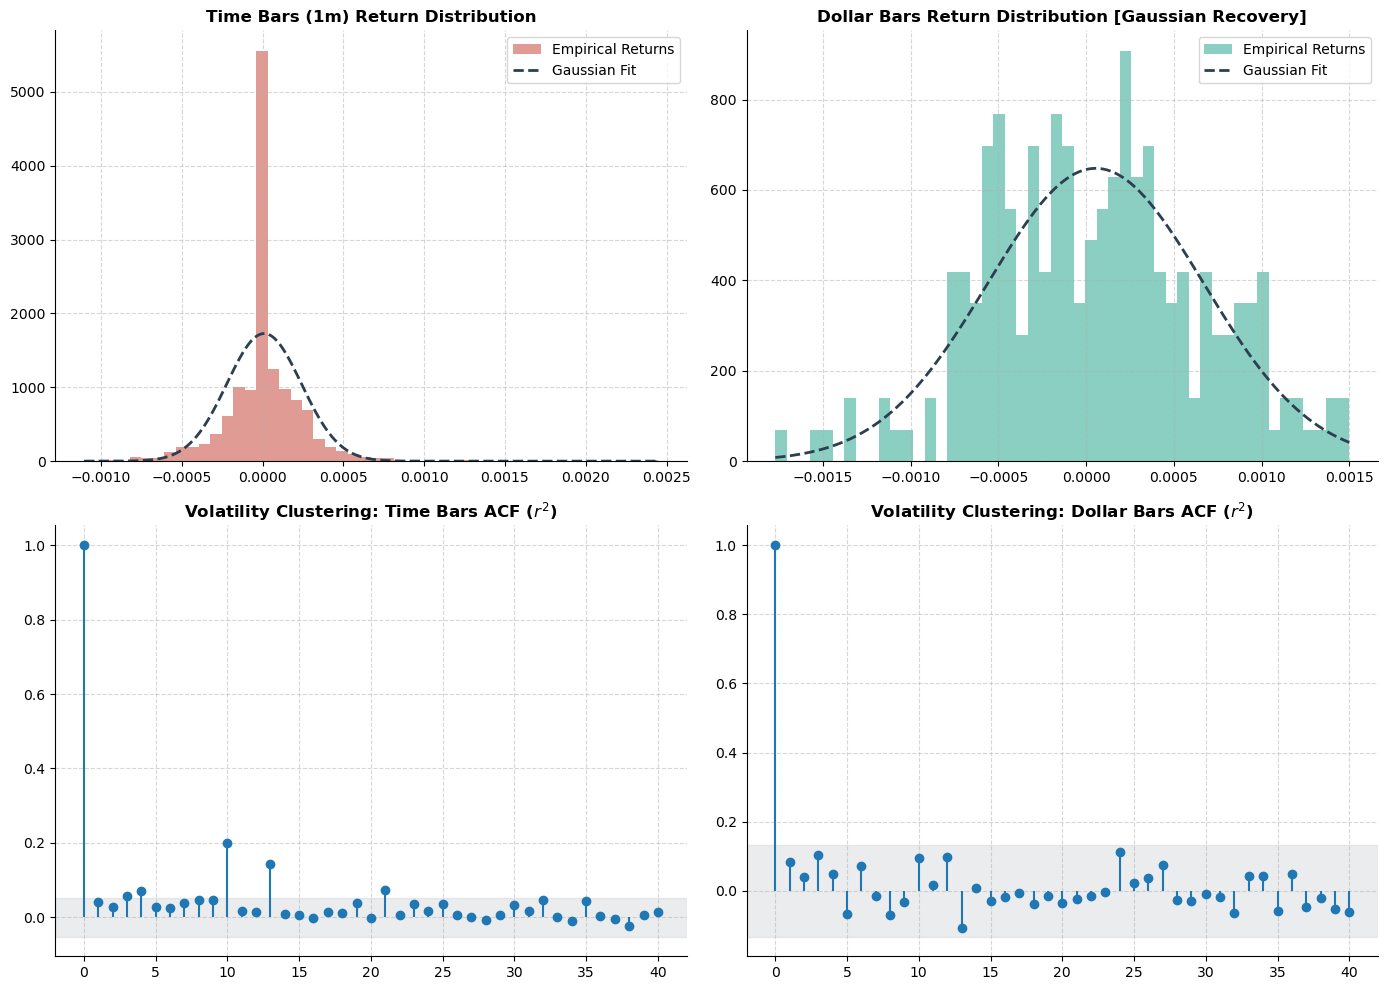

In [ ]:
def visualize_microstructure_matplotlib(time_bars, dollar_bars):
    r_time = time_bars['log_return'].dropna().values
    r_dollar = dollar_bars['log_return'].dropna().values

    COLOR_TIME, COLOR_DOLLAR, COLOR_GAUSS = '#C0392B', '#16A085', '#2C3E50'
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
    fig.patch.set_facecolor('white')

    for ax in axes.flat:
        ax.set_facecolor('white')
        ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # TIME BARS PDF
    axes[0, 0].hist(r_time, bins=50, density=True, color=COLOR_TIME, alpha=0.5, label='Empirical Returns')
    mu_t, std_t = stats.norm.fit(r_time)
    x_t = np.linspace(np.min(r_time), np.max(r_time), 200)
    axes[0, 0].plot(x_t, stats.norm.pdf(x_t, mu_t, std_t), color=COLOR_GAUSS, linestyle='--', lw=2, label='Gaussian Fit')
    axes[0, 0].set_title('Time Bars (1m) Return Distribution', fontweight='bold')
    axes[0, 0].legend()

    # DOLLAR BARS PDF
    axes[0, 1].hist(r_dollar, bins=50, density=True, color=COLOR_DOLLAR, alpha=0.5, label='Empirical Returns')
    mu_d, std_d = stats.norm.fit(r_dollar)
    x_d = np.linspace(np.min(r_dollar), np.max(r_dollar), 200)
    axes[0, 1].plot(x_d, stats.norm.pdf(x_d, mu_d, std_d), color=COLOR_GAUSS, linestyle='--', lw=2, label='Gaussian Fit')
    axes[0, 1].set_title('Dollar Bars Return Distribution [Gaussian Recovery]', fontweight='bold')
    axes[0, 1].legend()

    # AUTOCORRELATION
    lags = 40
    lag_arr = np.arange(lags + 1)
    
    # Time ACF
    acf_time = acf(r_time**2, nlags=lags, fft=True)
    conf_time = 1.96 / np.sqrt(len(r_time))
    axes[1, 0].stem(lag_arr, acf_time, markerfmt='o', basefmt=" ")
    axes[1, 0].axhspan(-conf_time, conf_time, color='#BDC3C7', alpha=0.3)
    axes[1, 0].set_title('Volatility Clustering: Time Bars ACF ($r^2$)', fontweight='bold')

    # Dollar ACF
    acf_dollar = acf(r_dollar**2, nlags=lags, fft=True)
    conf_dollar = 1.96 / np.sqrt(len(r_dollar))
    axes[1, 1].stem(lag_arr, acf_dollar, markerfmt='o', basefmt=" ")
    axes[1, 1].axhspan(-conf_dollar, conf_dollar, color='#BDC3C7', alpha=0.3)
    axes[1, 1].set_title('Volatility Clustering: Dollar Bars ACF ($r^2$)', fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_microstructure_matplotlib(time_bars, dollar_bars)


## Phase 4: Filtering Microstructure Noise
At ultra-high frequencies, order-book friction (Bid-Ask bounce) masquerades as variance. We calculate Realized Volatility across varying frequencies to build a Signature Plot, acting as a low-pass filter to identify where thermal noise decays into true latent volatility.


Calculating Realized Volatility across frequencies...


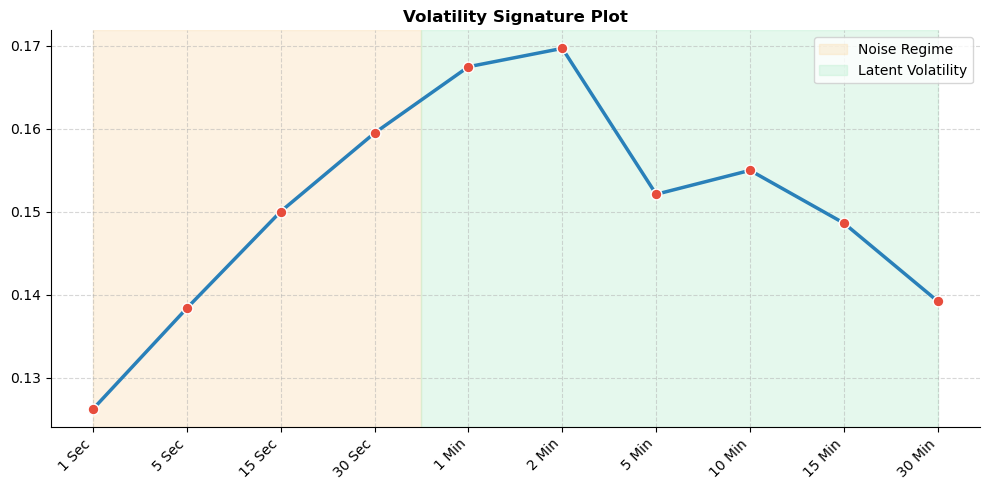

In [5]:
def plot_signature_curve(rv_df):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    x_pos = np.arange(len(rv_df))
    y_vals = rv_df['Annualized_RV'].values
    
    ax.plot(x_pos, y_vals, color='#2980B9', linewidth=2.5, zorder=3)
    ax.scatter(x_pos, y_vals, color='#E74C3C', s=60, zorder=4, edgecolor='white')
    
    ax.axvspan(0, 3.5, color='#FAD7A1', alpha=0.3, zorder=1, label='Noise Regime')
    ax.axvspan(3.5, len(rv_df)-1, color='#ABEBC6', alpha=0.3, zorder=1, label='Latent Volatility')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(rv_df['Label'], rotation=45, ha='right')
    ax.set_title('Volatility Signature Plot', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Calculate and plot
rv_df = calculate_volatility_signature(wrangler.df)
plot_signature_curve(rv_df)


## Phase 5: Predictive Kinematics (Order Flow Imbalance)
We apply a Ridge Regression model to test if net market force (Order Flow Imbalance) can predict future price acceleration. We strictly shift the target variable $t+1$ to ensure zero data leakage.


Resampling data to 10s intervals for predictive modeling...
Model Training Complete.
R-Squared (Out of Sample): 0.0039


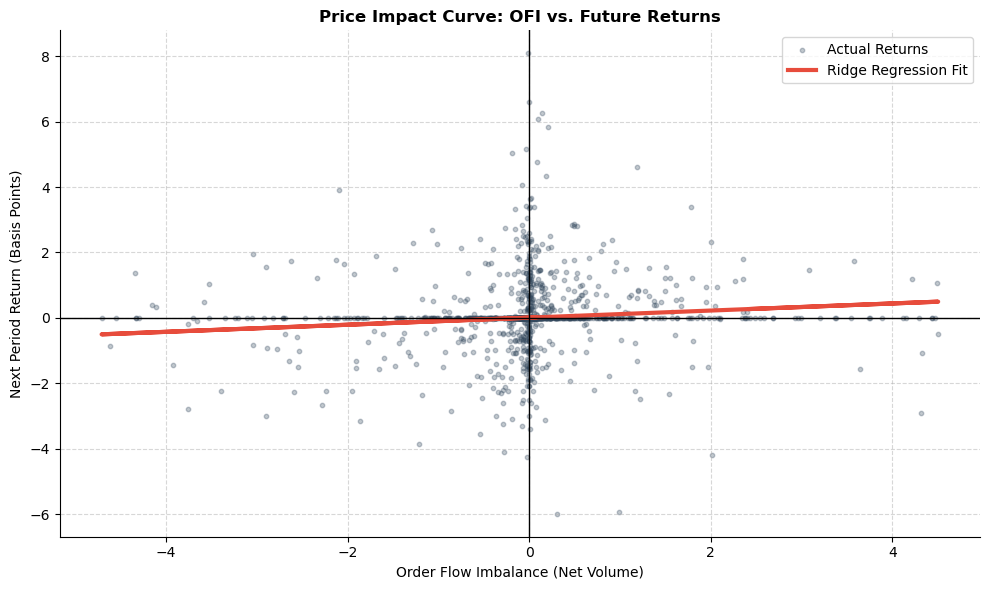

In [6]:
def plot_price_impact_curve(X_test, y_test, y_pred):
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.scatter(X_test, y_test, alpha=0.3, color='#34495E', s=10, label='Actual Returns')
    ax.plot(X_test, y_pred, color='#E74C3C', linewidth=3, label='Ridge Regression Fit')
    
    ax.axhline(0, color='black', linewidth=1, zorder=2)
    ax.axvline(0, color='black', linewidth=1, zorder=2)
    
    ax.set_title('Price Impact Curve: OFI vs. Future Returns', fontweight='bold')
    ax.set_xlabel('Order Flow Imbalance (Net Volume)')
    ax.set_ylabel('Next Period Return (Basis Points)')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Execute predictive modeling
clean_bars, model, X_test, y_test, y_pred = predictive_ofi_modeling(wrangler.df, freq='10s')

# Plot the impact curve
plot_price_impact_curve(X_test, y_test, y_pred)
